In [1]:
"""Sample predictions on synthetic and empirical batches, print shapes, and plot.

The utility first draws a batch list from a synthetic ``AICME`` data module
to compare tensor dimensions against an empirical ``StudyJSON`` dataset. For
both sources it samples stochastic predictions using
``model.sample_individual_prediction`` and reports the shapes of the context,
target, and predicted trajectories before rendering the empirical predictions
as a grid of ``StudyJSON`` records.

The shapes follow the project's conventions:
- Each batch has ``target_obs`` and ``context_obs`` tensors shaped
  ``[B, I, T, 1]``.
- ``model.sample_individual_prediction`` returns ``prediction_sample`` and
  ``prediction_time`` shaped ``[S, B, It, Tr, 1]``.
- Empirical predictions are converted to ``StudyJSON`` via
  :func:`prediction_to_study_jsons` and rendered as a grid.
"""

from __future__ import annotations

from pathlib import Path
from typing import List
import argparse
import sys

from torchtyping import TensorType as TT

from pff import config_dir, data_dir, reports_dir
from pff.config_classes.node_pk_config import NodePKConfig
from pff.data_empirical import (
    load_empirical_json_batches,
    load_empirical_hf_batches_as_dm,
    prediction_to_study_jsons,
)
from pff.datasets.aicme_datasets import (
    AICMECompartmentsDataBatch,
    AICMECompartmentsDataModule,
)
from pff.models.amortized_inference.aicme import AICMEPK
from pff.data_empirical.json_schema import StudyJSON
from pff.utils.plots.databatch_plot import (
    plot_list_list_study_json,
    plot_list_aicme_databatch,
    plot_study_json
)
from pff.data_empirical.builder import databatch_to_study_jsons

In [ ]:
from pathlib import Path
from dataclasses import dataclass
from pff import data_dir,config_dir,reports_dir

@dataclass
class NotebookConfig:
    yaml: Path
    split: str
    json: Path
    out: Path
    samples: int

    @classmethod
    def default(cls, config_dir: Path, data_dir: Path, reports_dir: Path):
        default_yaml = Path(config_dir) / "experiment_configs" / "node-pk" / "base-homogeneous.yaml"
        default_json = Path(data_dir) / "preprocessed" / "lenuzza_2016.json"
        default_out = Path(reports_dir) / "empirical_prediction_plot.png"

        return cls(
            yaml=default_yaml,
            split="train",
            json=default_json,
            out=default_out,
            samples=8,
        )

# Get defaults
args = NotebookConfig.default(config_dir, data_dir, reports_dir)

In [3]:
# 1) Load configuration ---------------------------------------------------
cfg: NodePKConfig = NodePKConfig.from_yaml(str(args.yaml))

# 2) Build synthetic data module and model -------------------------------
dm = AICMECompartmentsDataModule(cfg)
dm.prepare_data()
dm.setup()

model = AICMEPK(cfg)
model.eval()
loader = dm.test_dataloader()

synthetic_batch_list: List[AICMECompartmentsDataBatch] = next(iter(loader))
synthetic_batch = synthetic_batch_list[0]

In [4]:
forwards_, *_ = model(synthetic_batch_list,return_forward_report=True)
sampled_studies = model.sample_new_individuals_to_studyjson(
    synthetic_batch
)
one_sample_study = sampled_studies[0]

torch.Size([25, 1, 11, 1])
torch.Size([25, 1, 11, 1])
torch.Size([25, 1, 11, 1])


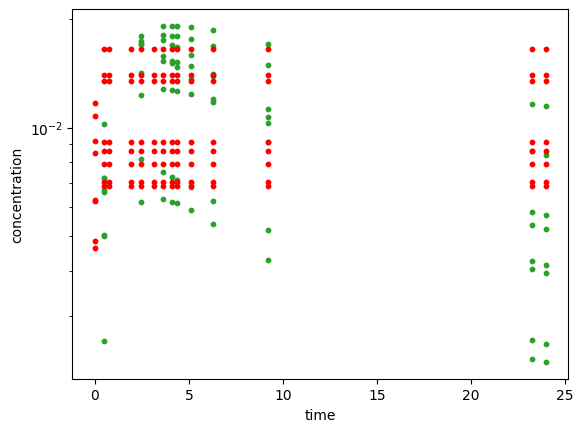

In [5]:
plot_study_json(one_sample_study)

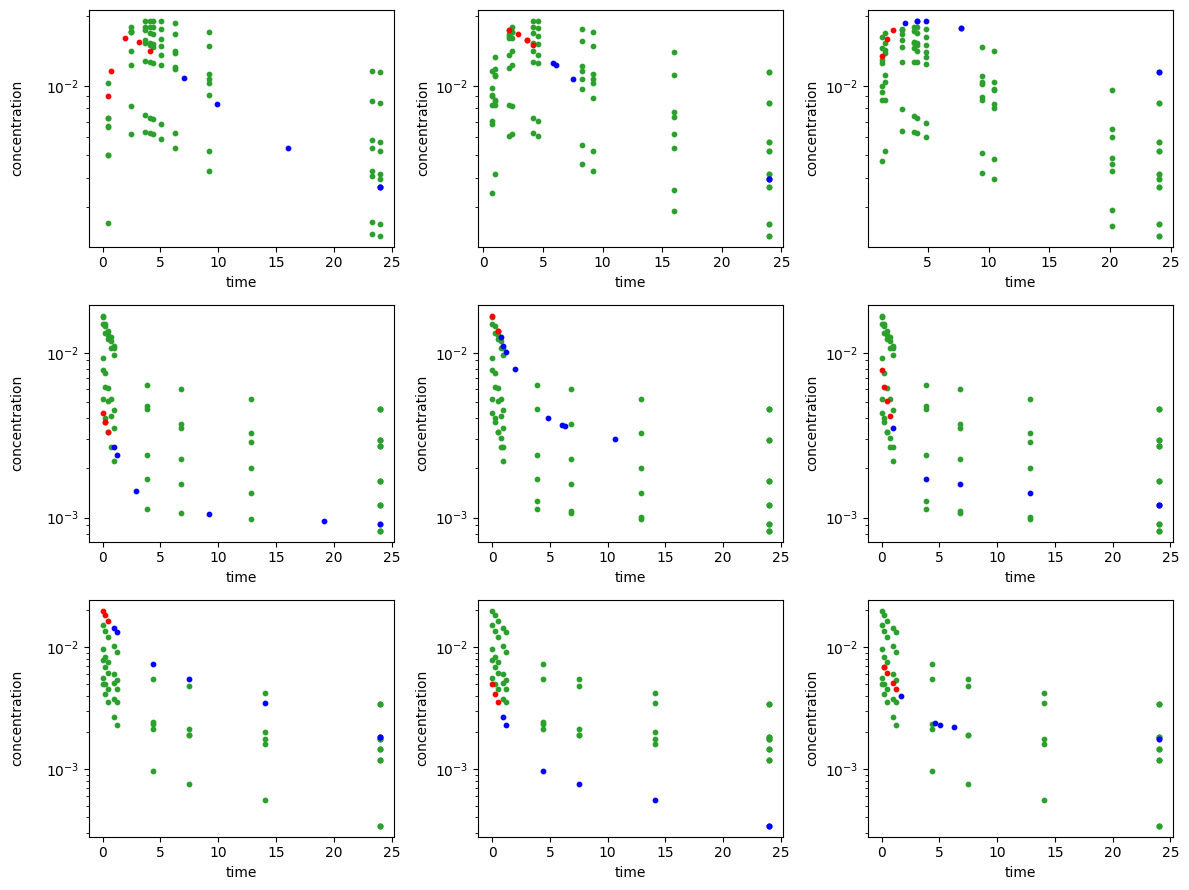

In [6]:
plot_list_aicme_databatch(synthetic_batch_list)

In [7]:
print("Synthetic batch list:")
for p, batch in enumerate(synthetic_batch_list):
    print(f"  Permutation {p}:")
    context_obs: TT["B", "Ic", "T", 1] = batch.context_obs
    target_obs: TT["B", "It", "T", 1] = batch.target_obs
    print(f"    context_obs shape: {context_obs.shape}")
    print(f"    target_obs shape: {target_obs.shape}")
    (
        syn_pred_sample,
        syn_pred_time,
        _,
        _,
    ) = model.sample_individual_prediction(batch, sample_size=args.samples)
    syn_pred_sample: TT["S", "B", "It", "Tr", 1]
    syn_pred_time: TT["S", "B", "It", "Tr", 1]
    print(f"    prediction_sample shape: {syn_pred_sample.shape}")
    print(f"    prediction_time shape: {syn_pred_time.shape}")

Synthetic batch list:
  Permutation 0:
    context_obs shape: torch.Size([25, 9, 11, 1])
    target_obs shape: torch.Size([25, 1, 5, 1])
    prediction_sample shape: torch.Size([8, 25, 1, 8, 1])
    prediction_time shape: torch.Size([8, 25, 1, 8, 1])
  Permutation 1:
    context_obs shape: torch.Size([25, 9, 11, 1])
    target_obs shape: torch.Size([25, 1, 5, 1])
    prediction_sample shape: torch.Size([8, 25, 1, 8, 1])
    prediction_time shape: torch.Size([8, 25, 1, 8, 1])
  Permutation 2:
    context_obs shape: torch.Size([25, 9, 11, 1])
    target_obs shape: torch.Size([25, 1, 5, 1])
    prediction_sample shape: torch.Size([8, 25, 1, 8, 1])
    prediction_time shape: torch.Size([8, 25, 1, 8, 1])


In [8]:
# 4) Load empirical batches ----------------------------------------------
# Shapes from the synthetic datamodule ``dm`` are reused when padding
# empirical observations.
from pff.datasets.aicme_datasets import (
    AICMECompartmentsDataBatch,
    build_reconstruction_db,
    list_of_databath_to_device,
)

#"cesarali/lenuzza-2016"


In [9]:
empirical_batch_list = load_empirical_hf_batches_as_dm("cesarali/lenuzza-2016", 
                                                       meta_dosing=cfg.dosing, 
                                                       datamodule=dm)
empirical_batch = empirical_batch_list[0]

print("Lenuzza")
for empirical_batch in empirical_batch_list:
    print("recon")
    recon_db = build_reconstruction_db(empirical_batch)

    print(recon_db.context_obs.shape)
    print(recon_db.target_obs.shape)

    print("original target")
    print(empirical_batch.context_obs.shape)
    print(empirical_batch.target_obs.shape)
    break

empirical_batch_list = load_empirical_hf_batches_as_dm("cesarali/Indometacin", 
                                                       meta_dosing=cfg.dosing, 
                                                       datamodule=dm)
empirical_batch = empirical_batch_list[0]

print("Indometacin")
for empirical_batch in empirical_batch_list:
    print("recon")
    recon_db = build_reconstruction_db(empirical_batch)

    print(recon_db.context_obs.shape)
    print(recon_db.target_obs.shape)

    print("original target")
    print(empirical_batch.context_obs.shape)
    print(empirical_batch.target_obs.shape)
    break

Lenuzza
recon
torch.Size([18, 9, 11, 1])
torch.Size([18, 1, 11, 1])
original target
torch.Size([18, 9, 11, 1])
torch.Size([18, 1, 5, 1])
Indometacin
recon
torch.Size([1, 9, 11, 1])
torch.Size([1, 1, 11, 1])
original target
torch.Size([1, 9, 11, 1])
torch.Size([1, 1, 5, 1])


In [10]:
#loss_outputs, mean_out, logvar_out, target_out, mask_out = model(empirical_batch_list,return_forward_report=True)

In [11]:
sampled_studies = model.sample_new_individuals_from_batchlist_to_study_json(
    empirical_batch_list
)

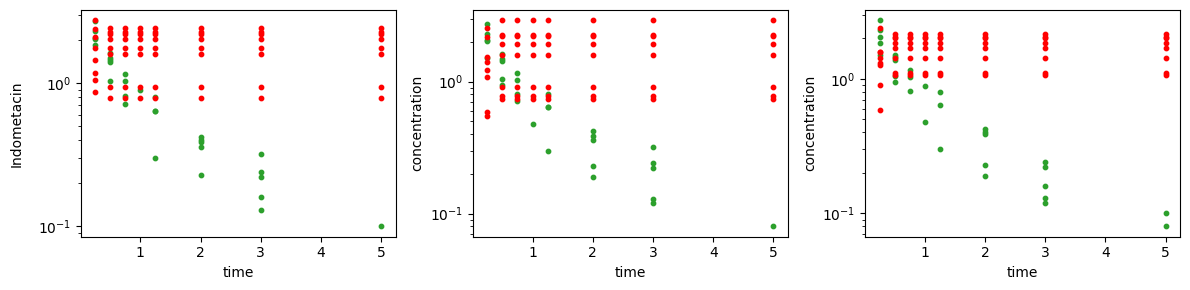

In [12]:
plot_list_list_study_json(sampled_studies)


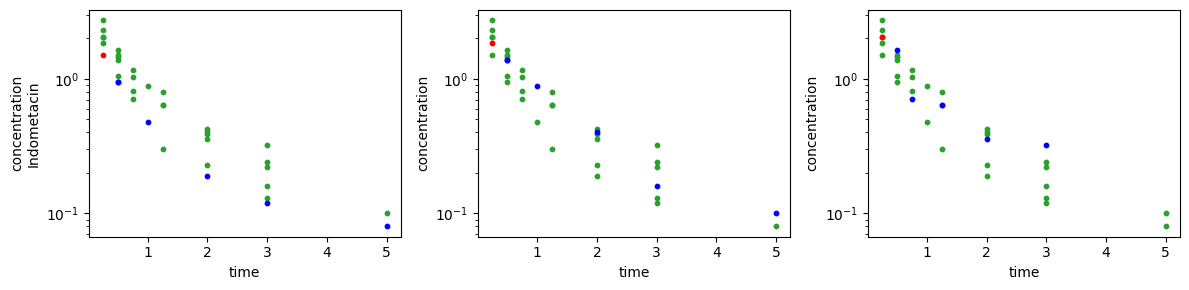

In [13]:
plot_list_aicme_databatch(empirical_batch_list)

Permutation 0:
  context_obs shape: torch.Size([25, 9, 11, 1])
  target_obs shape: torch.Size([25, 1, 5, 1])
  prediction_sample shape: torch.Size([8, 25, 1, 8, 1])
  prediction_time shape: torch.Size([8, 25, 1, 8, 1])
Permutation 1:
  context_obs shape: torch.Size([25, 9, 11, 1])
  target_obs shape: torch.Size([25, 1, 5, 1])
  prediction_sample shape: torch.Size([8, 25, 1, 8, 1])
  prediction_time shape: torch.Size([8, 25, 1, 8, 1])
Permutation 2:
  context_obs shape: torch.Size([25, 9, 11, 1])
  target_obs shape: torch.Size([25, 1, 5, 1])
  prediction_sample shape: torch.Size([8, 25, 1, 8, 1])
  prediction_time shape: torch.Size([8, 25, 1, 8, 1])


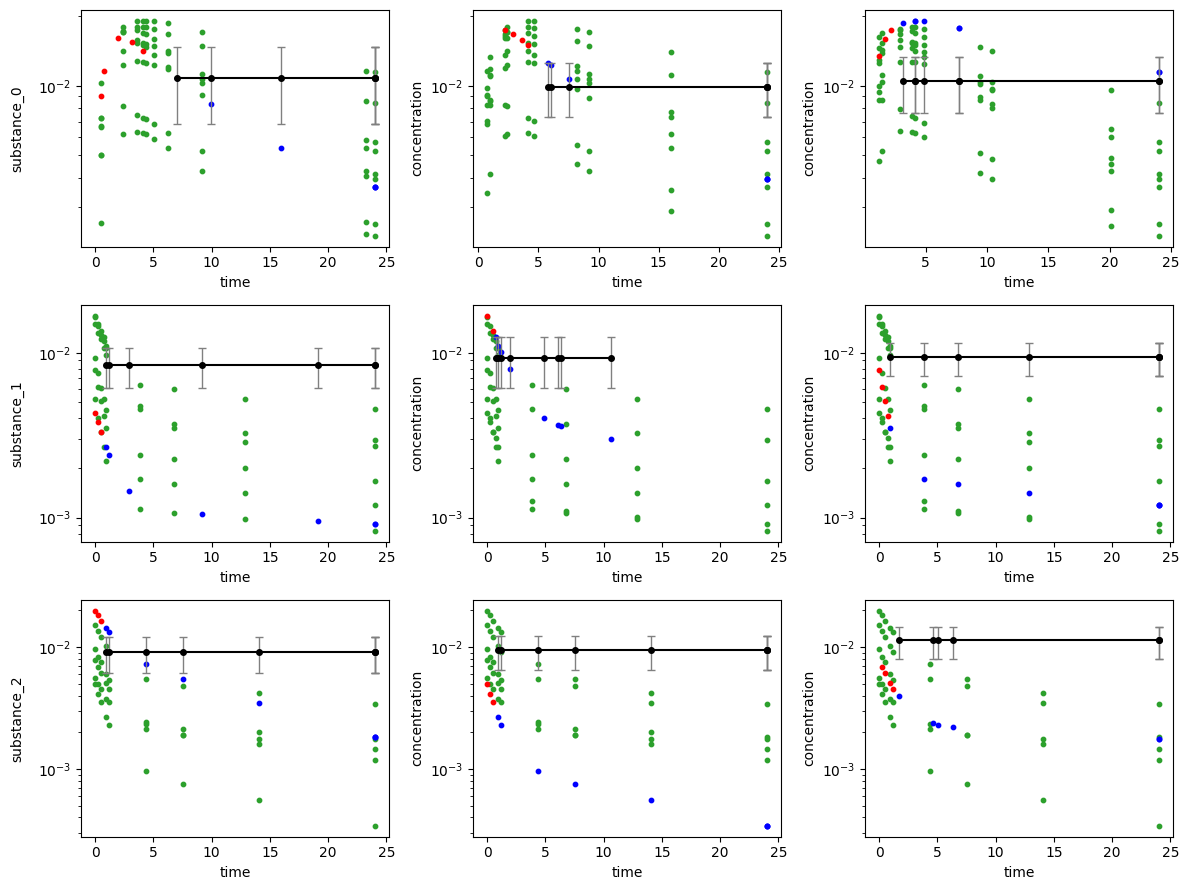

In [14]:
# 5) Sample predictions ---------------------------------------------------
studies_per_perm: List[List[StudyJSON]] = []
for p, batch in enumerate(synthetic_batch_list):
    print(f"Permutation {p}:")
    context_obs: TT["B", "Ic", "T", 1] = batch.context_obs
    target_obs: TT["B", "It", "T", 1] = batch.target_obs
    print(f"  context_obs shape: {context_obs.shape}")
    print(f"  target_obs shape: {target_obs.shape}")

    (
        prediction_sample,
        prediction_time,
        _,
        _,
    ) = model.sample_individual_prediction(batch, sample_size=args.samples)
    prediction_sample: TT["S", "B", "It", "Tr", 1]
    prediction_time: TT["S", "B", "It", "Tr", 1]
    print(f"  prediction_sample shape: {prediction_sample.shape}")
    print(f"  prediction_time shape: {prediction_time.shape}")

    studies = prediction_to_study_jsons(
        prediction_sample, prediction_time, batch, cfg.dosing
    )
    studies_per_perm.append(studies)

# 6) Plot grid of predictions --------------------------------------------
args.out.parent.mkdir(parents=True, exist_ok=True)
plot_list_list_study_json(studies_per_perm)

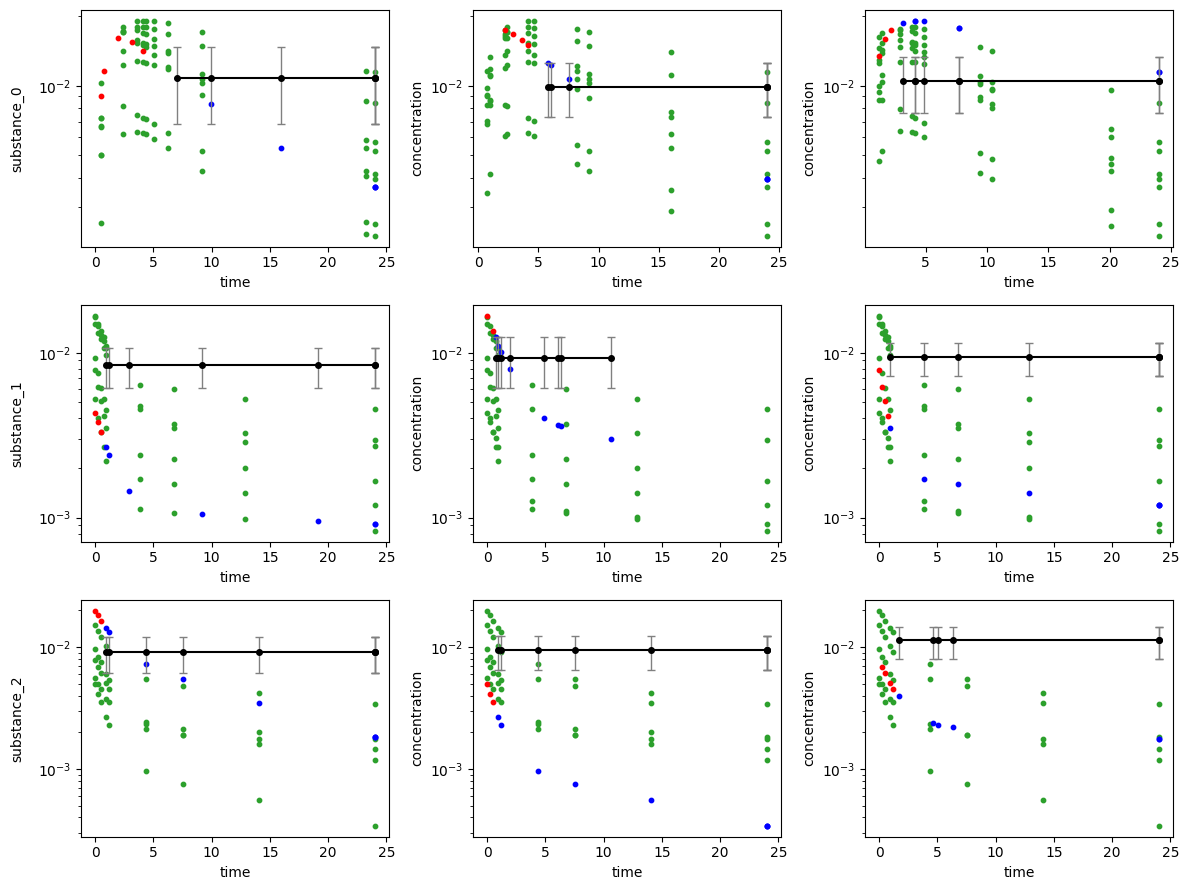

In [15]:
plot_list_list_study_json(studies_per_perm)